In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [4]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset (1).csv to placement_predict_50k Dataset (1) (1).csv


In [6]:
df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (38499, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0.0,66.7,2.2,49.4,47.8,0.0,Low,0.0,0.0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0.0,48.2,2.4,26.7,25.8,0.0,Low,0.0,0.0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0.0,73.8,2.8,67.7,41.5,0.0,Low,1.0,0.0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0.0,69.8,2.7,66.9,48.0,0.0,Mid,1.0,0.0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1.0,73.1,2.1,71.7,61.7,1.0,High,1.0,0.0,18.99


In [7]:
print(df.columns.tolist())

['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38499 entries, 0 to 38498
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           38499 non-null  int64  
 1   Gender              38499 non-null  object 
 2   City                38499 non-null  object 
 3   CollegeTier         38499 non-null  object 
 4   Stream              38499 non-null  object 
 5   Specialisation      38499 non-null  object 
 6   Hostel              38499 non-null  object 
 7   HistoryOfBacklogs   38499 non-null  object 
 8   SGPA_Sem1           38499 non-null  float64
 9   SGPA_Sem2           38499 non-null  float64
 10  SGPA_Sem3           38499 non-null  float64
 11  SGPA_Sem4           38499 non-null  float64
 12  SGPA_Sem5           38499 non-null  float64
 13  SGPA_Sem6           38499 non-null  float64
 14  SGPA_Sem7           38499 non-null  float64
 15  SGPA_Sem8           38499 non-null  float64
 16  CGPA

In [9]:
print(df.isnull().sum())

StudentID                0
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
CGPA                     0
AttendancePercent        1
Internships              1
Projects                 1
Workshops             3443
Certifications           1
Publications             1
AptitudeTestScore     3120
SoftSkillsRating      2727
CodingTestScore       2274
MockInterviewScore    3863
ExtraCurricular          1
CGPA_Tier                1
PlacementStatus          1
IsAnomaly                1
Salary Package           1
dtype: int64


In [10]:
print("PlacementStatus:")
print(df["PlacementStatus"].value_counts())

print("\nCGPA_Tier:")
print(df["CGPA_Tier"].value_counts())

PlacementStatus:
PlacementStatus
1.0    25308
0.0    13190
Name: count, dtype: int64

CGPA_Tier:
CGPA_Tier
High    12855
Low     12828
Mid     12815
Name: count, dtype: int64


In [11]:
exclude_cols = [
    "PlacementStatus",
    "CGPA_Tier",
    "Salary Package",
    "StudentID",
    "IsAnomaly"
]

X = df.drop(columns=exclude_cols, errors="ignore")

print("Number of features:", X.shape[1])
print(X.columns.tolist())

Number of features: 27
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular']


In [12]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular']

Categorical features:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs']


In [13]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [15]:
X_binary = df.drop(
    columns=[
        "PlacementStatus",
        "CGPA_Tier",
        "Salary Package",
        "StudentID",
        "IsAnomaly"
    ],
    errors="ignore"
)

y_binary = df["PlacementStatus"]

In [17]:
missing_y_indices = y_binary.isnull()
X_binary_cleaned = X_binary[~missing_y_indices]
y_binary_cleaned = y_binary[~missing_y_indices]

X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(
    X_binary_cleaned,
    y_binary_cleaned,
    test_size=0.20,
    random_state=42,
    stratify=y_binary_cleaned
)

print("Training samples:", X_train_bin.shape[0])
print("Validation samples:", X_val_bin.shape[0])

Training samples: 30798
Validation samples: 7700


In [18]:
binary_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [19]:
def evaluate_classifier(model, X_train, y_train, X_val, y_val):

    # Fit the model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    # Accuracy
    train_accuracy = accuracy_score(y_train, train_pred)
    val_accuracy = accuracy_score(y_val, val_pred)

    print("=" * 70)
    print("MODEL EVALUATION")
    print("=" * 70)

    print(f"\nTrain Accuracy: {train_accuracy:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")

    print("\nClassification Report - Validation Data")
    print("-" * 70)
    print(classification_report(y_val, val_pred))

    print("\nConfusion Matrix - Validation Data")
    print("-" * 70)
    print(confusion_matrix(y_val, val_pred))

    return {
        "model": model,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_predictions": train_pred,
        "val_predictions": val_pred
    }

In [20]:
binary_result = evaluate_classifier(
    binary_lr,
    X_train_bin,
    y_train_bin,
    X_val_bin,
    y_val_bin
)

MODEL EVALUATION

Train Accuracy: 0.9261
Validation Accuracy: 0.9171

Classification Report - Validation Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.90      0.86      0.88      2638
         1.0       0.93      0.95      0.94      5062

    accuracy                           0.92      7700
   macro avg       0.91      0.90      0.91      7700
weighted avg       0.92      0.92      0.92      7700


Confusion Matrix - Validation Data
----------------------------------------------------------------------
[[2261  377]
 [ 261 4801]]


In [21]:
X_multi = df.drop(
    columns=[
        "PlacementStatus",
        "CGPA_Tier",
        "Salary Package",
        "StudentID",
        "IsAnomaly"
    ],
    errors="ignore"
)

y_multi = df["CGPA_Tier"]

In [23]:
missing_y_multi_indices = y_multi.isnull()
X_multi_cleaned = X_multi[~missing_y_multi_indices]
y_multi_cleaned = y_multi[~missing_y_multi_indices]

X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(
    X_multi_cleaned,
    y_multi_cleaned,
    test_size=0.20,
    random_state=42,
    stratify=y_multi_cleaned
)

print("Training samples:", X_train_multi.shape[0])
print("Validation samples:", X_val_multi.shape[0])

Training samples: 30798
Validation samples: 7700


In [24]:
multi_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            multi_class="multinomial",
            solver="lbfgs",
            random_state=42
        ))
    ]
)

In [25]:
multi_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            solver="lbfgs",
            random_state=42
        ))
    ]
)

In [26]:
multi_result = evaluate_classifier(
    multi_lr,
    X_train_multi,
    y_train_multi,
    X_val_multi,
    y_val_multi
)

MODEL EVALUATION

Train Accuracy: 0.9689
Validation Accuracy: 0.9655

Classification Report - Validation Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

        High       0.98      0.97      0.97      2571
         Low       0.97      0.97      0.97      2566
         Mid       0.94      0.95      0.95      2563

    accuracy                           0.97      7700
   macro avg       0.97      0.97      0.97      7700
weighted avg       0.97      0.97      0.97      7700


Confusion Matrix - Validation Data
----------------------------------------------------------------------
[[2499    0   72]
 [   0 2496   70]
 [  60   64 2439]]


In [27]:
academic_features = [
    "SGPA_Sem1",
    "SGPA_Sem2",
    "SGPA_Sem3",
    "SGPA_Sem4",
    "SGPA_Sem5",
    "SGPA_Sem6",
    "SGPA_Sem7",
    "SGPA_Sem8",
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "Workshops",
    "Certifications",
    "Publications",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

academic_features = [
    col for col in academic_features
    if col in df.columns
]

print("Academic features:")
print(academic_features)

Academic features:
['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']


In [28]:
X_academic = df[academic_features]
y_academic = df["PlacementStatus"]

In [30]:
missing_y_acad_indices = y_academic.isnull()
X_academic_cleaned = X_academic[~missing_y_acad_indices]
y_academic_cleaned = y_academic[~missing_y_acad_indices]

X_train_acad, X_val_acad, y_train_acad, y_val_acad = train_test_split(
    X_academic_cleaned,
    y_academic_cleaned,
    test_size=0.20,
    random_state=42,
    stratify=y_academic_cleaned
)

In [31]:
academic_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [32]:
academic_lr = Pipeline(
    steps=[
        ("preprocessor", academic_preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [33]:
academic_result = evaluate_classifier(
    academic_lr,
    X_train_acad,
    y_train_acad,
    X_val_acad,
    y_val_acad
)

MODEL EVALUATION

Train Accuracy: 0.9167
Validation Accuracy: 0.9096

Classification Report - Validation Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.89      0.84      0.86      2638
         1.0       0.92      0.94      0.93      5062

    accuracy                           0.91      7700
   macro avg       0.90      0.89      0.90      7700
weighted avg       0.91      0.91      0.91      7700


Confusion Matrix - Validation Data
----------------------------------------------------------------------
[[2228  410]
 [ 286 4776]]


In [34]:
results_df = pd.DataFrame({
    "Model": [
        "Binary PlacementStatus LR",
        "Multinomial CGPA_Tier LR",
        "Academic PlacementStatus LR"
    ],
    "Train Accuracy": [
        binary_result["train_accuracy"],
        multi_result["train_accuracy"],
        academic_result["train_accuracy"]
    ],
    "Validation Accuracy": [
        binary_result["val_accuracy"],
        multi_result["val_accuracy"],
        academic_result["val_accuracy"]
    ]
})

results_df

,Model,Train Accuracy,Validation Accuracy
0,Binary PlacementStatus LR,0.926099,0.917143
1,Multinomial CGPA_Tier LR,0.968862,0.965455
2,Academic PlacementStatus LR,0.916715,0.909610


In [35]:
print(results_df.to_string(index=False))

                      Model  Train Accuracy  Validation Accuracy
  Binary PlacementStatus LR        0.926099             0.917143
   Multinomial CGPA_Tier LR        0.968862             0.965455
Academic PlacementStatus LR        0.916715             0.909610


In [36]:
feature_names_binary = (
    binary_lr
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients_binary = (
    binary_lr
    .named_steps["classifier"]
    .coef_[0]
)

coef_binary_df = pd.DataFrame({
    "Feature": feature_names_binary,
    "Coefficient": coefficients_binary
})

coef_binary_df["AbsoluteCoefficient"] = (
    coef_binary_df["Coefficient"].abs()
)

coef_binary_df = coef_binary_df.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

coef_binary_df.head(20)

,Feature,Coefficient,AbsoluteCoefficient
8,num__CGPA,-2.148572,2.148572
47,cat__HistoryOfBacklogs_No,1.383799,1.383799
16,num__SoftSkillsRating,1.106018,1.106018
10,num__Internships,1.029553,1.029553
4,num__SGPA_Sem5,1.017844,1.017844
6,num__SGPA_Sem7,0.952885,0.952885
7,num__SGPA_Sem8,0.910411,0.910411
48,cat__HistoryOfBacklogs_Yes,-0.778752,0.778752
11,num__Projects,0.762303,0.762303
5,num__SGPA_Sem6,0.587093,0.587093


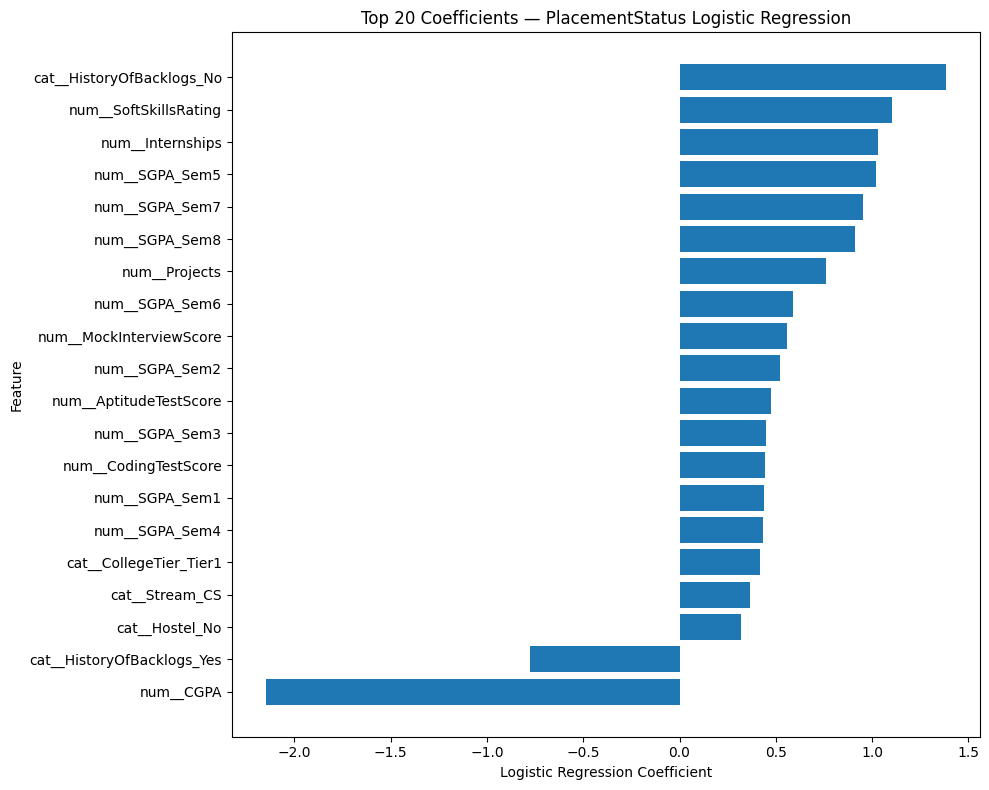

In [37]:
top20_binary = coef_binary_df.head(20).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_binary["Feature"],
    top20_binary["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 20 Coefficients — PlacementStatus Logistic Regression")

plt.tight_layout()
plt.show()

In [38]:
feature_names_multi = (
    multi_lr
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

multi_coefficients = (
    multi_lr
    .named_steps["classifier"]
    .coef_
)

print("Coefficient matrix shape:")
print(multi_coefficients.shape)

Coefficient matrix shape:
(3, 49)


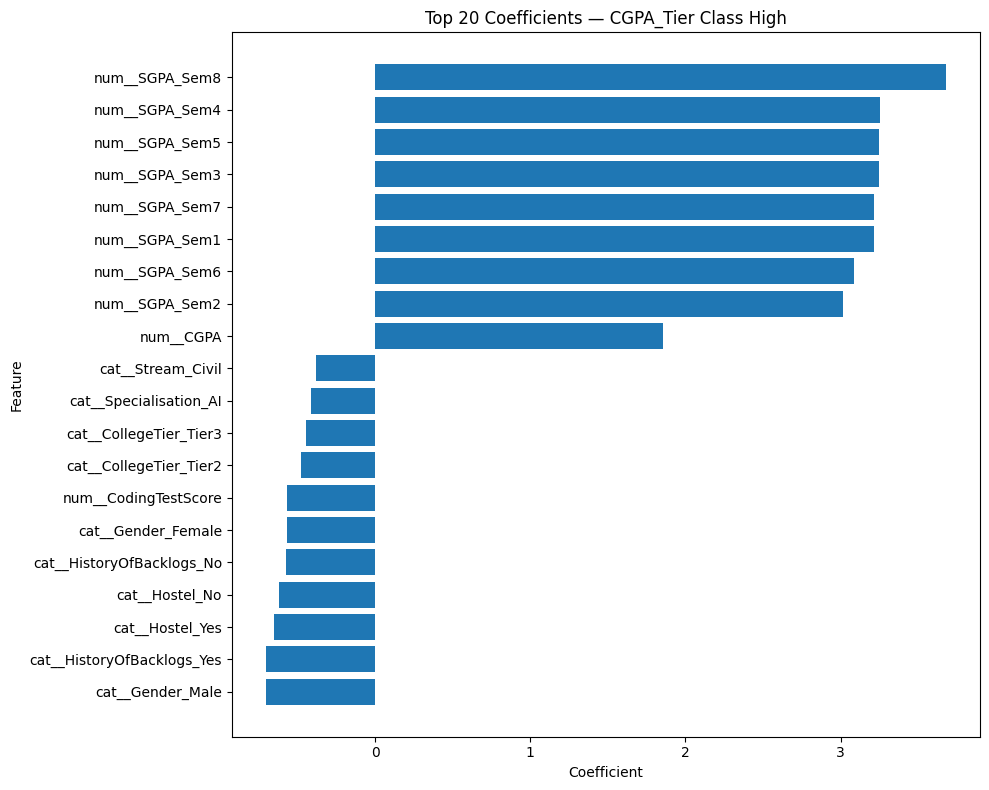

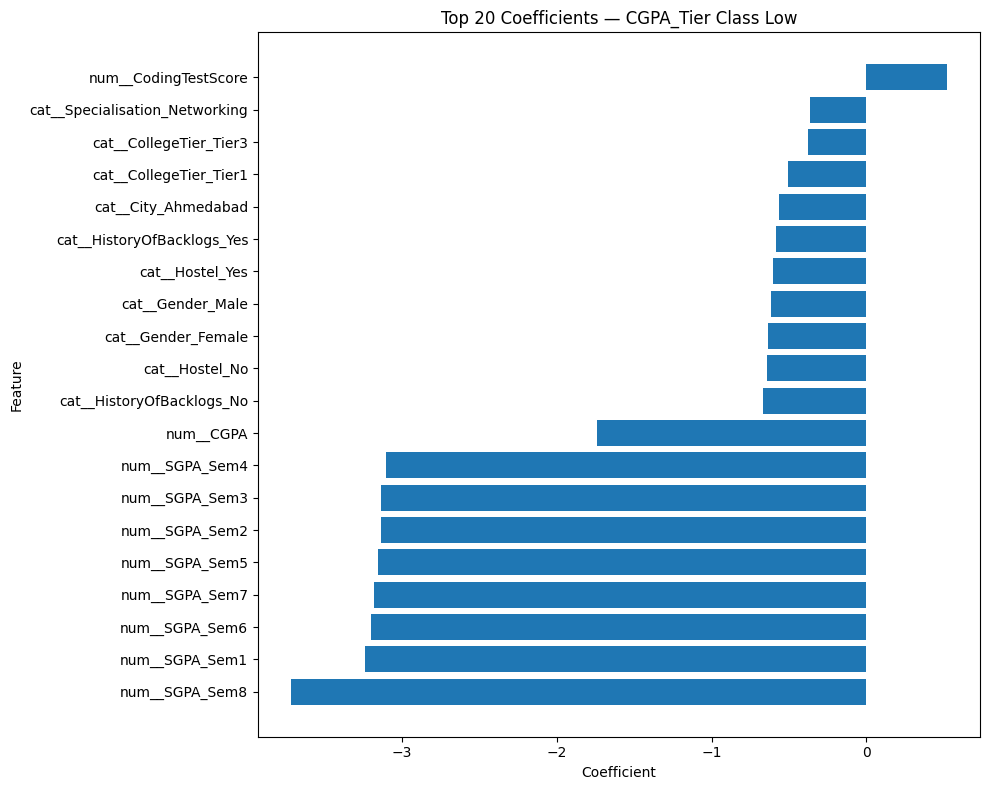

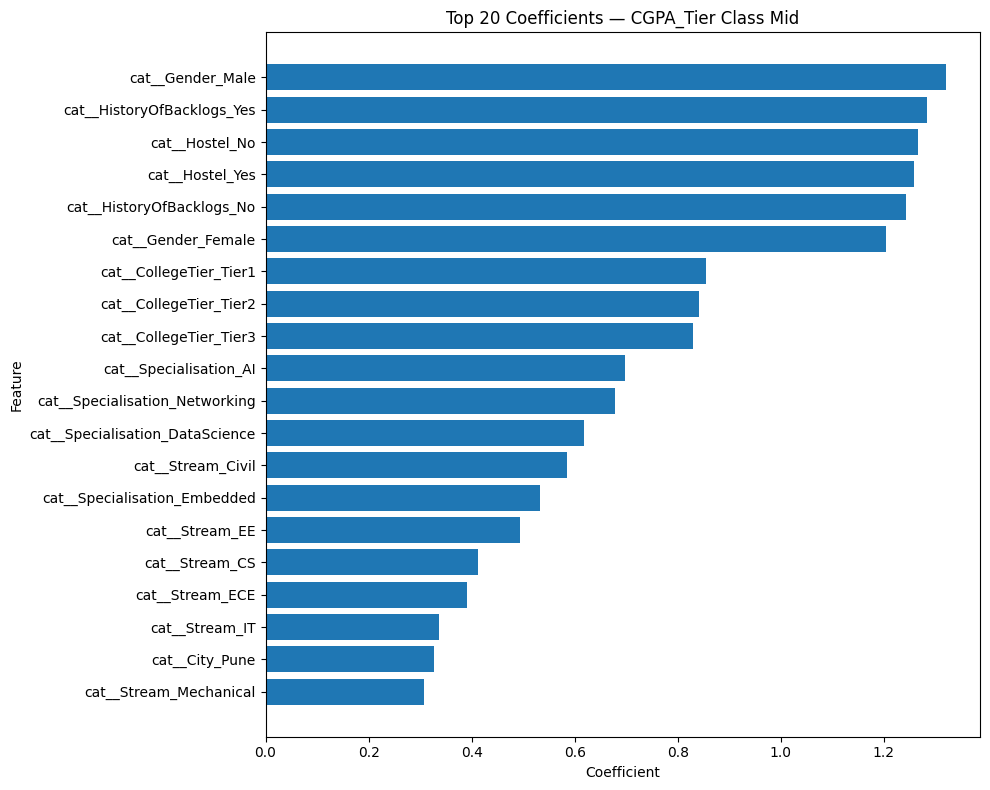

In [39]:
classes = multi_lr.named_steps["classifier"].classes_

for i, class_label in enumerate(classes):

    coef_df = pd.DataFrame({
        "Feature": feature_names_multi,
        "Coefficient": multi_coefficients[i]
    })

    coef_df["AbsoluteCoefficient"] = (
        coef_df["Coefficient"].abs()
    )

    coef_df = coef_df.sort_values(
        "AbsoluteCoefficient",
        ascending=False
    )

    top20 = coef_df.head(20).sort_values(
        "Coefficient"
    )

    plt.figure(figsize=(10, 8))

    plt.barh(
        top20["Feature"],
        top20["Coefficient"]
    )

    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title(
        f"Top 20 Coefficients — CGPA_Tier Class {class_label}"
    )

    plt.tight_layout()
    plt.show()

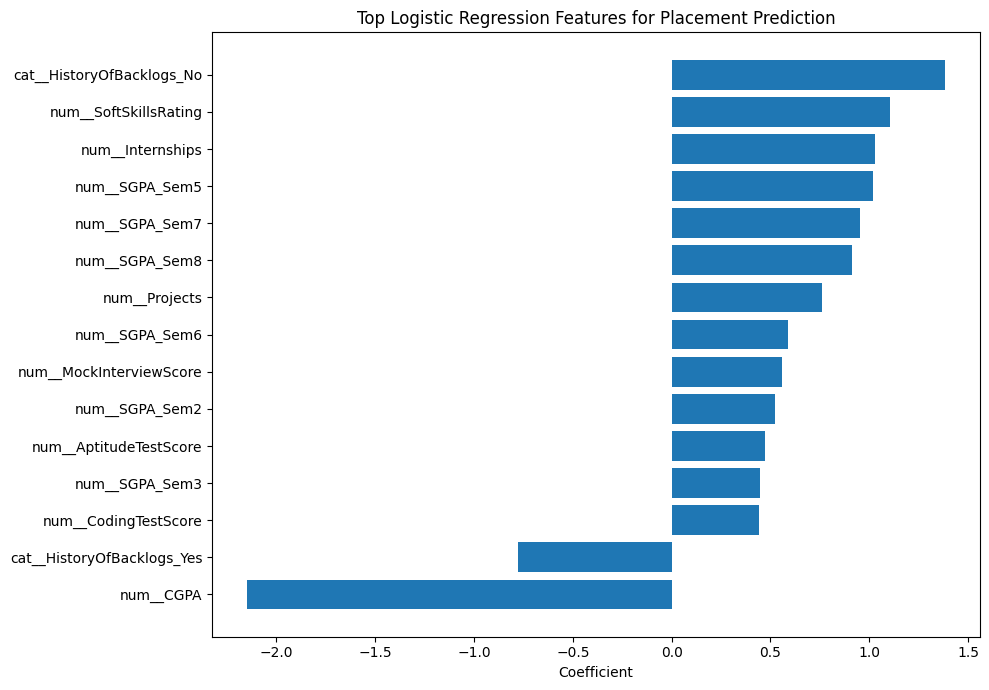

In [40]:
coef_plot = coef_binary_df.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    coef_plot["Feature"],
    coef_plot["Coefficient"]
)

plt.xlabel("Coefficient")
plt.title(
    "Top Logistic Regression Features for Placement Prediction"
)

plt.tight_layout()
plt.show()

In [41]:
print("\n\nMODEL 1: BINARY PLACEMENT STATUS")
binary_result = evaluate_classifier(
    binary_lr,
    X_train_bin,
    y_train_bin,
    X_val_bin,
    y_val_bin
)


print("\n\nMODEL 2: MULTINOMIAL CGPA TIER")
multi_result = evaluate_classifier(
    multi_lr,
    X_train_multi,
    y_train_multi,
    X_val_multi,
    y_val_multi
)


print("\n\nMODEL 3: ACADEMIC PLACEMENT STATUS")
academic_result = evaluate_classifier(
    academic_lr,
    X_train_acad,
    y_train_acad,
    X_val_acad,
    y_val_acad
)



MODEL 1: BINARY PLACEMENT STATUS
MODEL EVALUATION

Train Accuracy: 0.9261
Validation Accuracy: 0.9171

Classification Report - Validation Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.90      0.86      0.88      2638
         1.0       0.93      0.95      0.94      5062

    accuracy                           0.92      7700
   macro avg       0.91      0.90      0.91      7700
weighted avg       0.92      0.92      0.92      7700


Confusion Matrix - Validation Data
----------------------------------------------------------------------
[[2261  377]
 [ 261 4801]]


MODEL 2: MULTINOMIAL CGPA TIER
MODEL EVALUATION

Train Accuracy: 0.9689
Validation Accuracy: 0.9655

Classification Report - Validation Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

        High       0.98      0.97      0.97      2571
